# DiD Básico


In [10]:
# Vamos importar as bibliotecas necessárias para a análise
from pathlib import Path

import basedosdados as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

In [11]:
# Caminho onde os dados brutos estão salvos
raw_data = Path("raw_data")
output = Path("output")

In [12]:
output.mkdir(exist_ok=True)

In [13]:
# Ler a planilha, o resultado é um dataframe
df_raw = pd.read_excel(
    raw_data
    / "sinopses_estatisticas_pesquisa_covid19_censo_escolar_2020"
    / "Sinopse_Estatistica_do_Questionario_Resposta_Educacional_a_Pandemia_de_Covid_19_no Brasil_EducaЗ╞o_Brasica.xlsx",
    sheet_name="1.1 a 1.3",
    skiprows=8,
)

In [14]:
df_raw["CO_MUNICIPIO"] = df_raw["CO_MUNICIPIO"].astype("Int64")

In [16]:
# Vamos manter apenas municípios válidos, isto é, onde CO_MUNICIPIO não é null/na `notna`
# Mantem apenas linhas onde localização é Total e remove linhas onde a dependência
# é Total ou Pública
df = df_raw.loc[
    (df_raw["CO_MUNICIPIO"].notna())
    & (df_raw["TP_LOCALIZACAO"] == "Total")
    & (~df_raw["TP_DEPENDENCIA"].isin(["Total", "Pública"]))
]

In [17]:
# Durante o período de suspensão das atividades presenciais de ensino-aprendizagem,
# a escola adotou estratégias não presenciais de ensino?
# Percentual de escolas por município/rede que responderam "Sim"
counts, bin_edges = np.histogram(df["PERC_QUEST_3_S"].dropna(), bins=10)
for i in range(len(counts)):
    print(f"({bin_edges[i]}, {bin_edges[i + 1]}]: {counts[i]}")


(0.0, 10.0]: 52
(10.0, 20.0]: 6
(20.0, 30.0]: 3
(30.0, 40.0]: 2
(40.0, 50.0]: 3
(50.0, 60.0]: 12
(60.0, 70.0]: 46
(70.0, 80.0]: 47
(80.0, 90.0]: 102
(90.0, 100.0]: 6595


Como interpretar o resultado acima:

- Em 6595 município/rede entre 90 e 100% das escolas adotaram alguma medida
- Em 52 município/rede até 10% das escolas adotaram alguma medida


In [18]:
# Os municipios/rede sem estrategia são aqueles onde um baixo percentual
# de escolas adotaram alguma estretégia
df_municipios_sem_estrategia = df.loc[df["PERC_QUEST_3_S"] < 20]

In [19]:
df_municipios_sem_estrategia.shape

(58, 87)

In [20]:
# Visualizando algumas colunas do dataframe
df_municipios_sem_estrategia[
    ["CO_MUNICIPIO", "TP_LOCALIZACAO", "TP_DEPENDENCIA"]
].head()

,CO_MUNICIPIO,TP_LOCALIZACAO,TP_DEPENDENCIA
594,1200328,Total,Municipal
748,1300029,Total,Municipal
882,1301407,Total,Municipal
914,1301803,Total,Municipal
1102,1304005,Total,Municipal


In [5]:
# Para executar esse trecho é necessário ter um projeto no Google Cloud e um billing id.
# Para evitar isso, esse dado foi salvo em `raw_data/saeb_lp.csv`
# Então pule para a próxima célula para ler o arquivo csv usando `pd.read_csv`
bd.read_sql(
    """
select
    ano,
    id_municipio,
    round(avg(media), 2) as media, -- Média para o 5 e 9 ano
from basedosdados.br_inep_saeb.municipio
where localizacao = "total"
    and serie in (5, 9)
    and rede in ("federal", "estadual", "municipal", "privada")
    and disciplina = "LP"
group by ano, id_municipio""",
    billing_project_id="basedosdados-dev",
).to_csv(raw_data / "saeb_lp.csv", index=False)

Downloading: 100%|██████████|


In [21]:
df_saeb_lp = pd.read_csv(raw_data / "saeb_lp.csv")
df_saeb_lp["id_municipio"] = df_saeb_lp["id_municipio"].astype("Int64")

In [22]:
# Visualizando o dataframe
df_saeb_lp.head()

,ano,id_municipio,media
0,2011,4304655,206.03
1,2011,4323507,234.97
2,2011,2108454,178.44
3,2011,2507101,184.74
4,2011,3537404,219.81


In [23]:
# A coluna `sem_estrategia` marcar os municípios sem estrategia
df_saeb_lp["sem_estrategia"] = df_saeb_lp["id_municipio"].apply(
    lambda v: (
        1 if v in df_municipios_sem_estrategia["CO_MUNICIPIO"].values.tolist() else 0
    )
)

In [24]:
df_saeb_lp["sem_estrategia"].value_counts(dropna=False)

sem_estrategia
0    38131
1      404
Name: count, dtype: int64

No resultado acima temos 404 municípios marcados sem estrategia (sem_estrategia = 1).
O valor é maior que a quantidade de municípios encontrados na sinopse porque é uma
série temporal


In [25]:
# Criar variáveis necessárias para o did
df_saeb_lp["pos"] = (df_saeb_lp["ano"] == 2021).astype(int)  # Dummy pós-tratamento
df_saeb_lp["did"] = (
    df_saeb_lp["sem_estrategia"] * df_saeb_lp["pos"]
)  # Termo de interação

In [26]:
# Garantir que município seja categórico
df_saeb_lp["id_municipio"] = df_saeb_lp["id_municipio"].astype("category")

In [27]:
df_saeb_lp.head()

,ano,id_municipio,media,sem_estrategia,pos,did
0,2011,4304655,206.03,0,0,0
1,2011,4323507,234.97,0,0,0
2,2011,2108454,178.44,0,0,0
3,2011,2507101,184.74,0,0,0
4,2011,3537404,219.81,0,0,0


In [28]:
def plot_tendencias(df: pd.DataFrame, save: bool = False) -> None:
    """
    Plota evolução do SAEB para tratados vs controles
    """
    # Calcular médias por grupo e ano
    medias = df.groupby(["ano", "sem_estrategia"])["media"].mean().reset_index()

    # Criar gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    for grupo in [0, 1]:
        dados_grupo = medias[medias["sem_estrategia"] == grupo]
        label = "Sem estratégia" if grupo == 1 else "Com estratégia"
        marker = "o" if grupo == 1 else "s"

        ax.plot(
            dados_grupo["ano"],  # type: ignore
            dados_grupo["media"],  # type: ignore
            marker=marker,
            markersize=10,
            linewidth=2.5,
            label=label,
            alpha=0.8,
        )

    # Linha vertical no tratamento
    ax.axvline(
        x=2020,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.6,
        label="Início da Pandemia",
    )

    ax.set_xlabel("Ano", fontsize=12, fontweight="bold")
    ax.set_ylabel("SAEB Médio", fontsize=12, fontweight="bold")
    # ax.set_title(
    #     "Evolução do SAEB: Tendências Paralelas\n(Teste Visual)",
    #     fontsize=14,
    #     fontweight="bold",
    # )
    ax.legend(fontsize=11, loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save:
        plt.savefig(output / "tendencias_paralelas.png", dpi=300, bbox_inches="tight")

    plt.show()

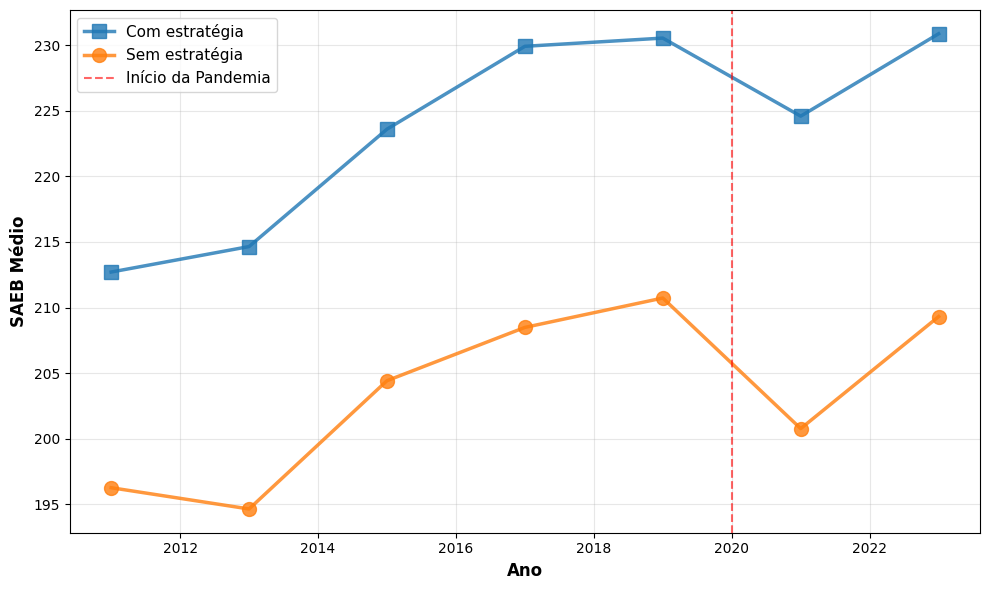

In [29]:
# Executar
plot_tendencias(df_saeb_lp, save=True)

# Modelo DiD Simples

- SAEB_it|Y_it = β₀ + β₁·Tratamento_i + β₂·Pós_t + β₃·(Tratamento_i × Pós_t) + ε_it
- SAEB_it|Y_it: Nota média do município i no tempo t
- Tratamento_i: Dummy = 1 se município não adotou estratégias, 0 caso contrário
  - Tratamento representa uma exposição negativa: estar no grupo tratado significa pertencer ao conjunto de municípios com baixa adoção, ou ausência quase generalizada, de estratégias não presenciais
- Pós_t: Dummy = 1 se ano é 2021, 0 se é 2019
- Tratamento_i × Pós_t: Termo de interação (o DiD propriamente dito)
- ε_it: Erro aleatório


In [31]:
def modelo_did_basico(df: pd.DataFrame):
    """
    Estima DiD básico via OLS
    """
    print("\n" + "=" * 80)
    print("MODELO 1: DiD BÁSICO (OLS)")
    print("=" * 80 + "\n")

    # Fórmula
    formula = "media ~ sem_estrategia + pos + did"

    # Estimar modelo
    modelo = smf.ols(formula, data=df).fit(
        cov_type="cluster",
        cov_kwds={"groups": df["id_municipio"]},  # type: ignore
    )

    print(modelo.summary())

    # Interpretar coeficiente DiD
    coef_did = modelo.params["did"]
    pvalor = modelo.pvalues["did"]

    print("\n" + "=" * 80)
    print("INTERPRETAÇÃO DO EFEITO DiD:")
    print("=" * 80)
    print(f"Coeficiente DiD: {coef_did:.4f}")
    print(f"P-valor: {pvalor:.4f}")
    print(
        f"Significância: {'***' if pvalor < 0.01 else '**' if pvalor < 0.05 else '*' if pvalor < 0.1 else 'Não significativo'}"
    )

    if coef_did < 0:
        print(
            f"\n➡️  Municípios SEM estratégias tiveram queda ADICIONAL de {abs(coef_did):.2f} pontos no SAEB"
        )
        print("    em relação aos municípios COM estratégias.")
    else:
        print(
            f"\n➡️  Municípios SEM estratégias tiveram ganho ADICIONAL de {coef_did:.2f} pontos no SAEB"
        )
        print("    em relação aos municípios COM estratégias (resultado inesperado!).")

    return modelo

In [32]:
modelo_did_basico_resultado = modelo_did_basico(df_saeb_lp)


MODELO 1: DiD BÁSICO (OLS)

                            OLS Regression Results                            
Dep. Variable:                  media   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     82.92
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           1.77e-52
Time:                        21:16:11   Log-Likelihood:            -1.7099e+05
No. Observations:               38535   AIC:                         3.420e+05
Df Residuals:                   38531   BIC:                         3.420e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      

# Resultados

1. O grupos tratamento e controle são bem diferentes, provavelmente a condição econômica foi um determinante para aplicar estratégia na pandemia.

- Municípios **sem** estratégia **Já** eram muito diferentes antes da pandemia
- Tinham SAEB 21.4 pontos menor que municípios com estratégia em 2019

2. Em média, houve melhora de 1.57 pontos de 2019 para 2021 (pos = +1.57)

- Recuperação pós retorno presencial

3. Municípios **sem** estratégias tiveram queda **adicional** de 3.25 pontos no SAEB em relação aos municípios **com** estratégias. (did = -3.25)


In [33]:
with open(output / "regression_results.tex", "w") as f:
    f.write(modelo_did_basico_resultado.summary().as_latex())